## Setup

In [126]:
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# Estilo acadêmico
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'font.size': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'lines.linewidth': 1.5,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

ROOT = Path('.').resolve()
CLIENT_LOG = ROOT / 'esp_client.log'
SERVER_LOG = ROOT / 'server.log'

print(f"Working directory: {ROOT}")
print(f"Client log: {CLIENT_LOG.exists()}")
print(f"Server log: {SERVER_LOG.exists()}")

Working directory: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague
Client log: True
Server log: True


## Parsing Cliente

In [127]:
def load_client_log(path=CLIENT_LOG):
    """Parse CSTATS format: CSTATS;t_ms;packets_sent;packets_received;inflight;rtt_us;jitter_us;packet_window;packet_burst;pacing_rate_bps
    Note: RTT and Jitter are in microseconds (us), converted to milliseconds (ms)"""
    rows = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line.startswith('CSTATS;'):
                continue
            parts = line.split(';')
            if len(parts) != 10:
                continue
            try:
                rows.append({
                    't_ms': int(parts[1]),
                    'packets_sent': int(parts[2]),
                    'packets_received': int(parts[3]),
                    'inflight': int(parts[4]),
                    'rtt_ms': float(parts[5]) / 1000.0,  # Convert microseconds to milliseconds
                    'jitter_ms': float(parts[6]) / 1000.0,  # Convert microseconds to milliseconds
                    'packet_window': int(parts[7]),
                    'packet_burst': int(parts[8]),
                    'pacing_rate_bps': float(parts[9]),
                })
            except (ValueError, IndexError):
                continue
    
    df = pd.DataFrame(rows)
    if not df.empty:
        df['t_client_s'] = df['t_ms'] / 1000.0
        df = df.sort_values('t_client_s').reset_index(drop=True)
        print(f"\n✓ Cliente: {len(df)} amostras")
        print(f"  Tempo: [{df['t_client_s'].min():.3f}, {df['t_client_s'].max():.3f}] s")
        print(f"  Pacotes enviados: {df['packets_sent'].iloc[-1]} (total)")
        print(f"  RTT: {df['rtt_ms'].mean():.2f} ± {df['rtt_ms'].std():.2f} ms")
        print(f"  Jitter: {df['jitter_ms'].mean():.2f} ± {df['jitter_ms'].std():.2f} ms")
        print(f"  Pacing: {df['pacing_rate_bps'].mean()/1e6:.2f} ± {df['pacing_rate_bps'].std()/1e6:.2f} Mbps")
    return df

try:
    df_client = load_client_log()
    display(df_client.head())
except FileNotFoundError:
    print(f"✗ Cliente não encontrado: {CLIENT_LOG}")
    df_client = pd.DataFrame()


✓ Cliente: 11444 amostras
  Tempo: [0.162, 179.989] s
  Pacotes enviados: 11646 (total)
  RTT: 221.48 ± 11.05 ms
  Jitter: 5.30 ± 6.34 ms
  Pacing: 0.64 ± 0.22 Mbps


,t_ms,packets_sent,packets_received,inflight,rtt_ms,jitter_ms,packet_window,packet_burst,pacing_rate_bps,t_client_s
0,162,13,1,12,162.338,0.000,3,1,13581.0,0.162
1,173,13,2,11,150.381,11.957,3,1,18270.0,0.173
2,184,13,3,10,148.256,2.125,3,1,23058.0,0.184
3,191,13,4,9,153.041,4.785,3,1,26877.0,0.191
4,202,13,5,8,140.619,12.422,4,1,30509.0,0.202


## Parsing Servidor

In [128]:
def load_server_log(path=SERVER_LOG):
    """Parse RECVER format - 200ms buckets (non-overlapping)"""
    rows = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            m = server_re.match(line)
            if not m:
                continue
            g = m.groupdict()
            try:
                rows.append({
                    'time_sec': float(g['time_sec']),
                    'rcvd_rate_mbps': float(g['rcvd']),
                    'sent_rate_mbps': float(g['sent']),
                    'ce_rate_percent': float(g['mark_pct']),
                    'ce_count': int(g['ce']),
                    'ce_total': int(g['mark_total']),
                    'loss_rate_percent': float(g['lost_pct']),
                    'loss_count': int(g['lost']),
                    'loss_total': int(g['lost_total']),
                })
            except (ValueError, KeyError):
                continue
    
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values('time_sec').reset_index(drop=True)
        
        # Clamp loss_rate_percent to valid range [0, 100] due to server counter artifacts
        df['loss_rate_percent'] = df['loss_rate_percent'].clip(0, 100)
        
        print(f"\n✓ Servidor: {len(df)} amostras (200ms buckets)")
        print(f"  Tempo: [{df['time_sec'].min():.3f}, {df['time_sec'].max():.3f}] s")
        print(f"  RX throughput: {df['rcvd_rate_mbps'].mean():.2f} ± {df['rcvd_rate_mbps'].std():.2f} Mbps")
        print(f"  CE-mark rate: {df['ce_rate_percent'].mean():.2f} ± {df['ce_rate_percent'].std():.2f} %")
        print(f"  Loss rate: {df['loss_rate_percent'].mean():.4f} ± {df['loss_rate_percent'].std():.4f} %")
    return df

try:
    df_server = load_server_log()
    display(df_server.head())
except FileNotFoundError:
    print(f"✗ Servidor não encontrado: {SERVER_LOG}")
    df_server = pd.DataFrame()


✓ Servidor: 844 amostras (200ms buckets)
  Tempo: [7.960, 187.900] s
  RX throughput: 0.78 ± 0.38 Mbps
  CE-mark rate: 0.00 ± 0.00 %
  Loss rate: 0.0846 ± 1.0107 %


,time_sec,rcvd_rate_mbps,sent_rate_mbps,ce_rate_percent,ce_count,ce_total,loss_rate_percent,loss_count,loss_total
0,7.96,11.168,0.208,0.0,0,1,0.0,0,1
1,8.23,0.408,0.008,0.0,0,13,0.0,0,13
2,8.43,0.410,0.008,0.0,0,7,0.0,0,7
3,8.78,0.122,0.002,0.0,0,8,0.0,0,8
4,8.99,0.527,0.010,0.0,0,9,0.0,0,9


## Metadados do Teste

In [129]:
def extract_metadata(path=CLIENT_LOG):
    """Extract test metadata from client log header"""
    meta = {}
    try:
        with open(path, 'r') as f:
            for line in f:
                line = line.strip()
                if line.startswith('IoT Node ID:'):
                    meta['IoT Node ID'] = line.split(':', 1)[1].strip()
                elif line.startswith('Test Scenario:'):
                    meta['Test Scenario'] = line.split(':', 1)[1].strip()
                elif line.startswith('Payload Size:'):
                    meta['Payload Size'] = line.split(':', 1)[1].strip()
                elif line.startswith('Initial Burst Limit:'):
                    meta['Initial Burst Limit'] = line.split(':', 1)[1].strip()
                elif line.startswith('Duration:'):
                    meta['Duration'] = line.split(':', 1)[1].strip()
                elif line.startswith('ECN'):
                    meta['ECN'] = line.split(':', 1)[1].strip()
                elif line.startswith('Gateway CC Algorithm:'):
                    meta['Gateway CC Algorithm'] = line.split(':', 1)[1].strip()
                elif line.startswith('Gateway Qdisc:'):
                    meta['Gateway Qdisc'] = line.split(':', 1)[1].strip()
    except FileNotFoundError:
        pass
    return meta

metadata = extract_metadata()
print("\n📋 Test Metadata:")
for k, v in metadata.items():
    print(f"  {k}: {v}")


📋 Test Metadata:
  IoT Node ID: 1
  Test Scenario: High Load
  ECN: 0
  Payload Size: 1396 bytes (header: 13 + extra: 1383)
  Initial Burst Limit: 3 packets
  Duration: 180 seconds
  Gateway CC Algorithm: reno
  Gateway Qdisc: fq_codel


## Compute Goodput (RX / Pacing)

In [130]:
# Prepare goodput metric (cliente only)
if not df_client.empty:
    # Convert pacing_rate_bps to Mbps for goodput calculation
    df_client['pacing_rate_mbps'] = df_client['pacing_rate_bps'] / 1e6
    
    # Goodput = RX / Pacing (both in Mbps)
    # But we don't have RX from client directly, so goodput will be estimated differently
    # For now, mark it as NA
    print(f"✓ Cliente prepared: {len(df_client)} rows")
else:
    print("✗ Client data unavailable")

✓ Cliente prepared: 11444 rows


## 📊 Análise de Transmissão (Cliente ↔ Servidor)

In [ ]:
# Análise Comparativa: Cliente (TX) vs Servidor (RX)
if not df_client.empty and not df_server.empty:
    # === PACOTES ===
    # Cliente: total de pacotes enviados (acumulativo)
    client_packets_sent = df_client['packets_sent'].iloc[-1]
    
    # Servidor: total de pacotes recebidos
    # Usar loss_total (acumulativo) que representa todos os pacotes que chegaram no servidor
    # ou somar ce_total que é o incremento por bucket
    server_packets_received = df_server['ce_total'].sum()
    
    # Pacotes com CE-mark (mesmo valor do acumulado)
    server_packets_marked = df_server['ce_count'].sum()
    
    # Pacotes perdidos
    packets_lost_total = client_packets_sent - server_packets_received
    packets_loss_rate = (packets_lost_total / client_packets_sent * 100) if client_packets_sent > 0 else 0
    
    # === BYTES ===
    # Extrair tamanho do pacote dos metadados
    # Formato: "Payload Size: 1396 bytes (header: 13 + extra: 1383)"
    PACKET_SIZE_BYTES = 1396  # Valor padrão
    if 'Payload Size' in metadata:
        payload_str = metadata['Payload Size']
        # Extrair primeiro número (tamanho total em bytes)
        match = re.search(r'(\d+)\s*bytes', payload_str)
        if match:
            PACKET_SIZE_BYTES = int(match.group(1))
    
    client_bytes_sent = client_packets_sent * PACKET_SIZE_BYTES
    
    # Servidor: calcular bytes recebidos a partir do throughput
    # Throughput está em Mbps, precisamos integrar no tempo
    if 'rcvd_rate_mbps' in df_server.columns and len(df_server) > 1:
        # Calcular bytes aproximados: soma de (rate * dt) para cada intervalo
        server_bytes_received = 0
        for i in range(1, len(df_server)):
            dt_sec = df_server['time_sec'].iloc[i] - df_server['time_sec'].iloc[i-1]
            rate_mbps = df_server['rcvd_rate_mbps'].iloc[i]
            bytes_in_interval = (rate_mbps * 1e6 / 8) * dt_sec  # Mbps -> bytes/s -> bytes
            server_bytes_received += bytes_in_interval
    else:
        server_bytes_received = 0
    
    bytes_lost = client_bytes_sent - server_bytes_received
    bytes_loss_rate = (bytes_lost / client_bytes_sent * 100) if client_bytes_sent > 0 else 0
    
    # === RELATÓRIO ===
    print("="*60)
    print("📦 ANÁLISE DE TRANSMISSÃO: Cliente → Servidor")
    print("="*60)
    print(f"\n{'Métrica':<40} {'Cliente (TX)':<15} {'Servidor (RX)':<15} {'Perda':<15}")
    print("-"*60)
    print(f"{'Pacotes':<40} {client_packets_sent:<15,} {server_packets_received:<15,} {packets_lost_total:<15,}")
    print(f"{'Taxa de perda de pacotes':<40} {'':<15} {'':<15} {packets_loss_rate:>14.2f}%")
    print(f"{'Bytes ({PACKET_SIZE_BYTES} bytes/pkt)':<40} {client_bytes_sent:<15,} {int(server_bytes_received):<15,} {int(bytes_lost):<15,}")
    print(f"{'Taxa de perda de bytes':<40} {'':<15} {'':<15} {bytes_loss_rate:>14.2f}%")
    print("-"*60)
    print(f"\nℹ️  Pacotes com CE-mark: {server_packets_marked:,}")
    print(f"ℹ️  Taxa de marcação ECN: {(server_packets_marked / server_packets_received * 100) if server_packets_received > 0 else 0:.2f}%")
    
    # Armazenar no summary
    transmission_stats = {
        'packet_size_bytes': PACKET_SIZE_BYTES,
        'client_packets_sent': client_packets_sent,
        'server_packets_received': server_packets_received,
        'server_packets_marked': server_packets_marked,
        'packets_lost': packets_lost_total,
        'packet_loss_rate_percent': packets_loss_rate,
        'ecn_mark_rate_percent': (server_packets_marked / server_packets_received * 100) if server_packets_received > 0 else 0,
        'client_bytes_sent_est': client_bytes_sent,
        'server_bytes_received_est': int(server_bytes_received),
        'bytes_lost_est': int(bytes_lost),
        'byte_loss_rate_percent': bytes_loss_rate,
    }
else:
    print("⚠️  Dados insuficientes para análise de transmissão")
    transmission_stats = {}


📦 ANÁLISE DE TRANSMISSÃO: Cliente → Servidor

Métrica                                  Cliente (TX)    Servidor (RX)   Perda          
------------------------------------------------------------
Pacotes                                  11,646          0               11,646         
Taxa de perda de pacotes                                                         100.00%
Bytes ({PACKET_SIZE_BYTES} bytes/pkt)    16,257,816      17,102,727      -844,911       
Taxa de perda de bytes                                                            -5.20%
------------------------------------------------------------

ℹ️  Pacotes com CE-mark: 0
ℹ️  Taxa de marcação ECN: 0.00%


## Plotting Functions

In [132]:
def plot_client_metrics(df_client, metadata):
    """Plot RTT, Jitter, Inflight, Pacing Rate"""
    if df_client.empty:
        print("No client data to plot")
        return
    
    fig, axes = plt.subplots(4, 1, figsize=(12, 10))
    fig.suptitle('Client Metrics (ESP32 - UDP-Prague)', fontsize=13, fontweight='bold')
    
    # (A) RTT
    ax = axes[0]
    ax.plot(df_client['t_client_s'], df_client['rtt_ms'], color='#2E86AB', linewidth=1.5, label='RTT')
    ax.set_ylabel('RTT (ms)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(A) Round Trip Time', fontsize=10)
    
    # (B) Jitter
    ax = axes[1]
    ax.plot(df_client['t_client_s'], df_client['jitter_ms'], color='#A23B72', linewidth=1.5, label='Jitter')
    ax.set_ylabel('Jitter (ms)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(B) Jitter (Stability)', fontsize=10)
    
    # (C) Inflight
    ax = axes[2]
    ax.plot(df_client['t_client_s'], df_client['inflight'], color='#F18F01', linewidth=1.5, label='Inflight')
    ax.set_ylabel('Inflight (packets)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(C) In-Flight Packets (CC Behavior)', fontsize=10)
    
    # (D) Pacing Rate
    ax = axes[3]
    ax.plot(df_client['t_client_s'], df_client['pacing_rate_mbps'], color='#06A77D', linewidth=1.5, label='Pacing Rate')
    ax.set_ylabel('Pacing Rate (Mbps)', fontsize=10)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(D) Pacing Rate (Adaptation)', fontsize=10)
    
    plt.tight_layout()
    return fig

def plot_server_metrics(df_server, metadata):
    """Plot RX Throughput, CE-mark Rate, Loss Rate"""
    if df_server.empty:
        print("No server data to plot")
        return
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 9))
    fig.suptitle('Server Metrics (DualPI2 Gateway)', fontsize=13, fontweight='bold')
    
    # (E) RX Throughput
    ax = axes[0]
    ax.plot(df_server['time_sec'], df_server['rcvd_rate_mbps'], color='#1E88E5', linewidth=1.5, label='RX Throughput')
    ax.set_ylabel('Throughput (Mbps)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(E) Received Throughput', fontsize=10)
    
    # (F) CE-mark Rate
    ax = axes[1]
    ax.plot(df_server['time_sec'], df_server['ce_rate_percent'], color='#D32F2F', linewidth=1.5, label='CE-mark Rate')
    ax.set_ylabel('CE-mark Rate (%)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(F) CE-Mark Rate (L4S Signal)', fontsize=10)
    
    # (G) Loss Rate
    ax = axes[2]
    ax.plot(df_server['time_sec'], df_server['loss_rate_percent'], color='#FF6F00', linewidth=1.5, label='Loss Rate')
    ax.set_ylabel('Loss Rate (%)', fontsize=10)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(G) Packet Loss', fontsize=10)
    
    plt.tight_layout()
    return fig

def plot_cdf_rtt(df_client):
    """Plot CDF of RTT"""
    if df_client.empty:
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    rtt_sorted = np.sort(df_client['rtt_ms'].dropna())
    cdf = np.arange(1, len(rtt_sorted) + 1) / len(rtt_sorted)
    
    ax.plot(rtt_sorted, cdf * 100, color='#2E86AB', linewidth=2, label='RTT CDF')
    ax.set_xlabel('RTT (ms)', fontsize=11)
    ax.set_ylabel('Probability (%)', fontsize=11)
    ax.set_title('(I) CDF of RTT (Client)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    return fig

print("✓ Plotting functions defined")

✓ Plotting functions defined


## Generate and Save Plots

Output name: prague_academic_high_load_node1_ccreno_qdiscfq_codel_ecn0
✓ Saved: prague_academic_high_load_node1_ccreno_qdiscfq_codel_ecn0_client_metrics.png
✓ Saved: prague_academic_high_load_node1_ccreno_qdiscfq_codel_ecn0_client_metrics.png


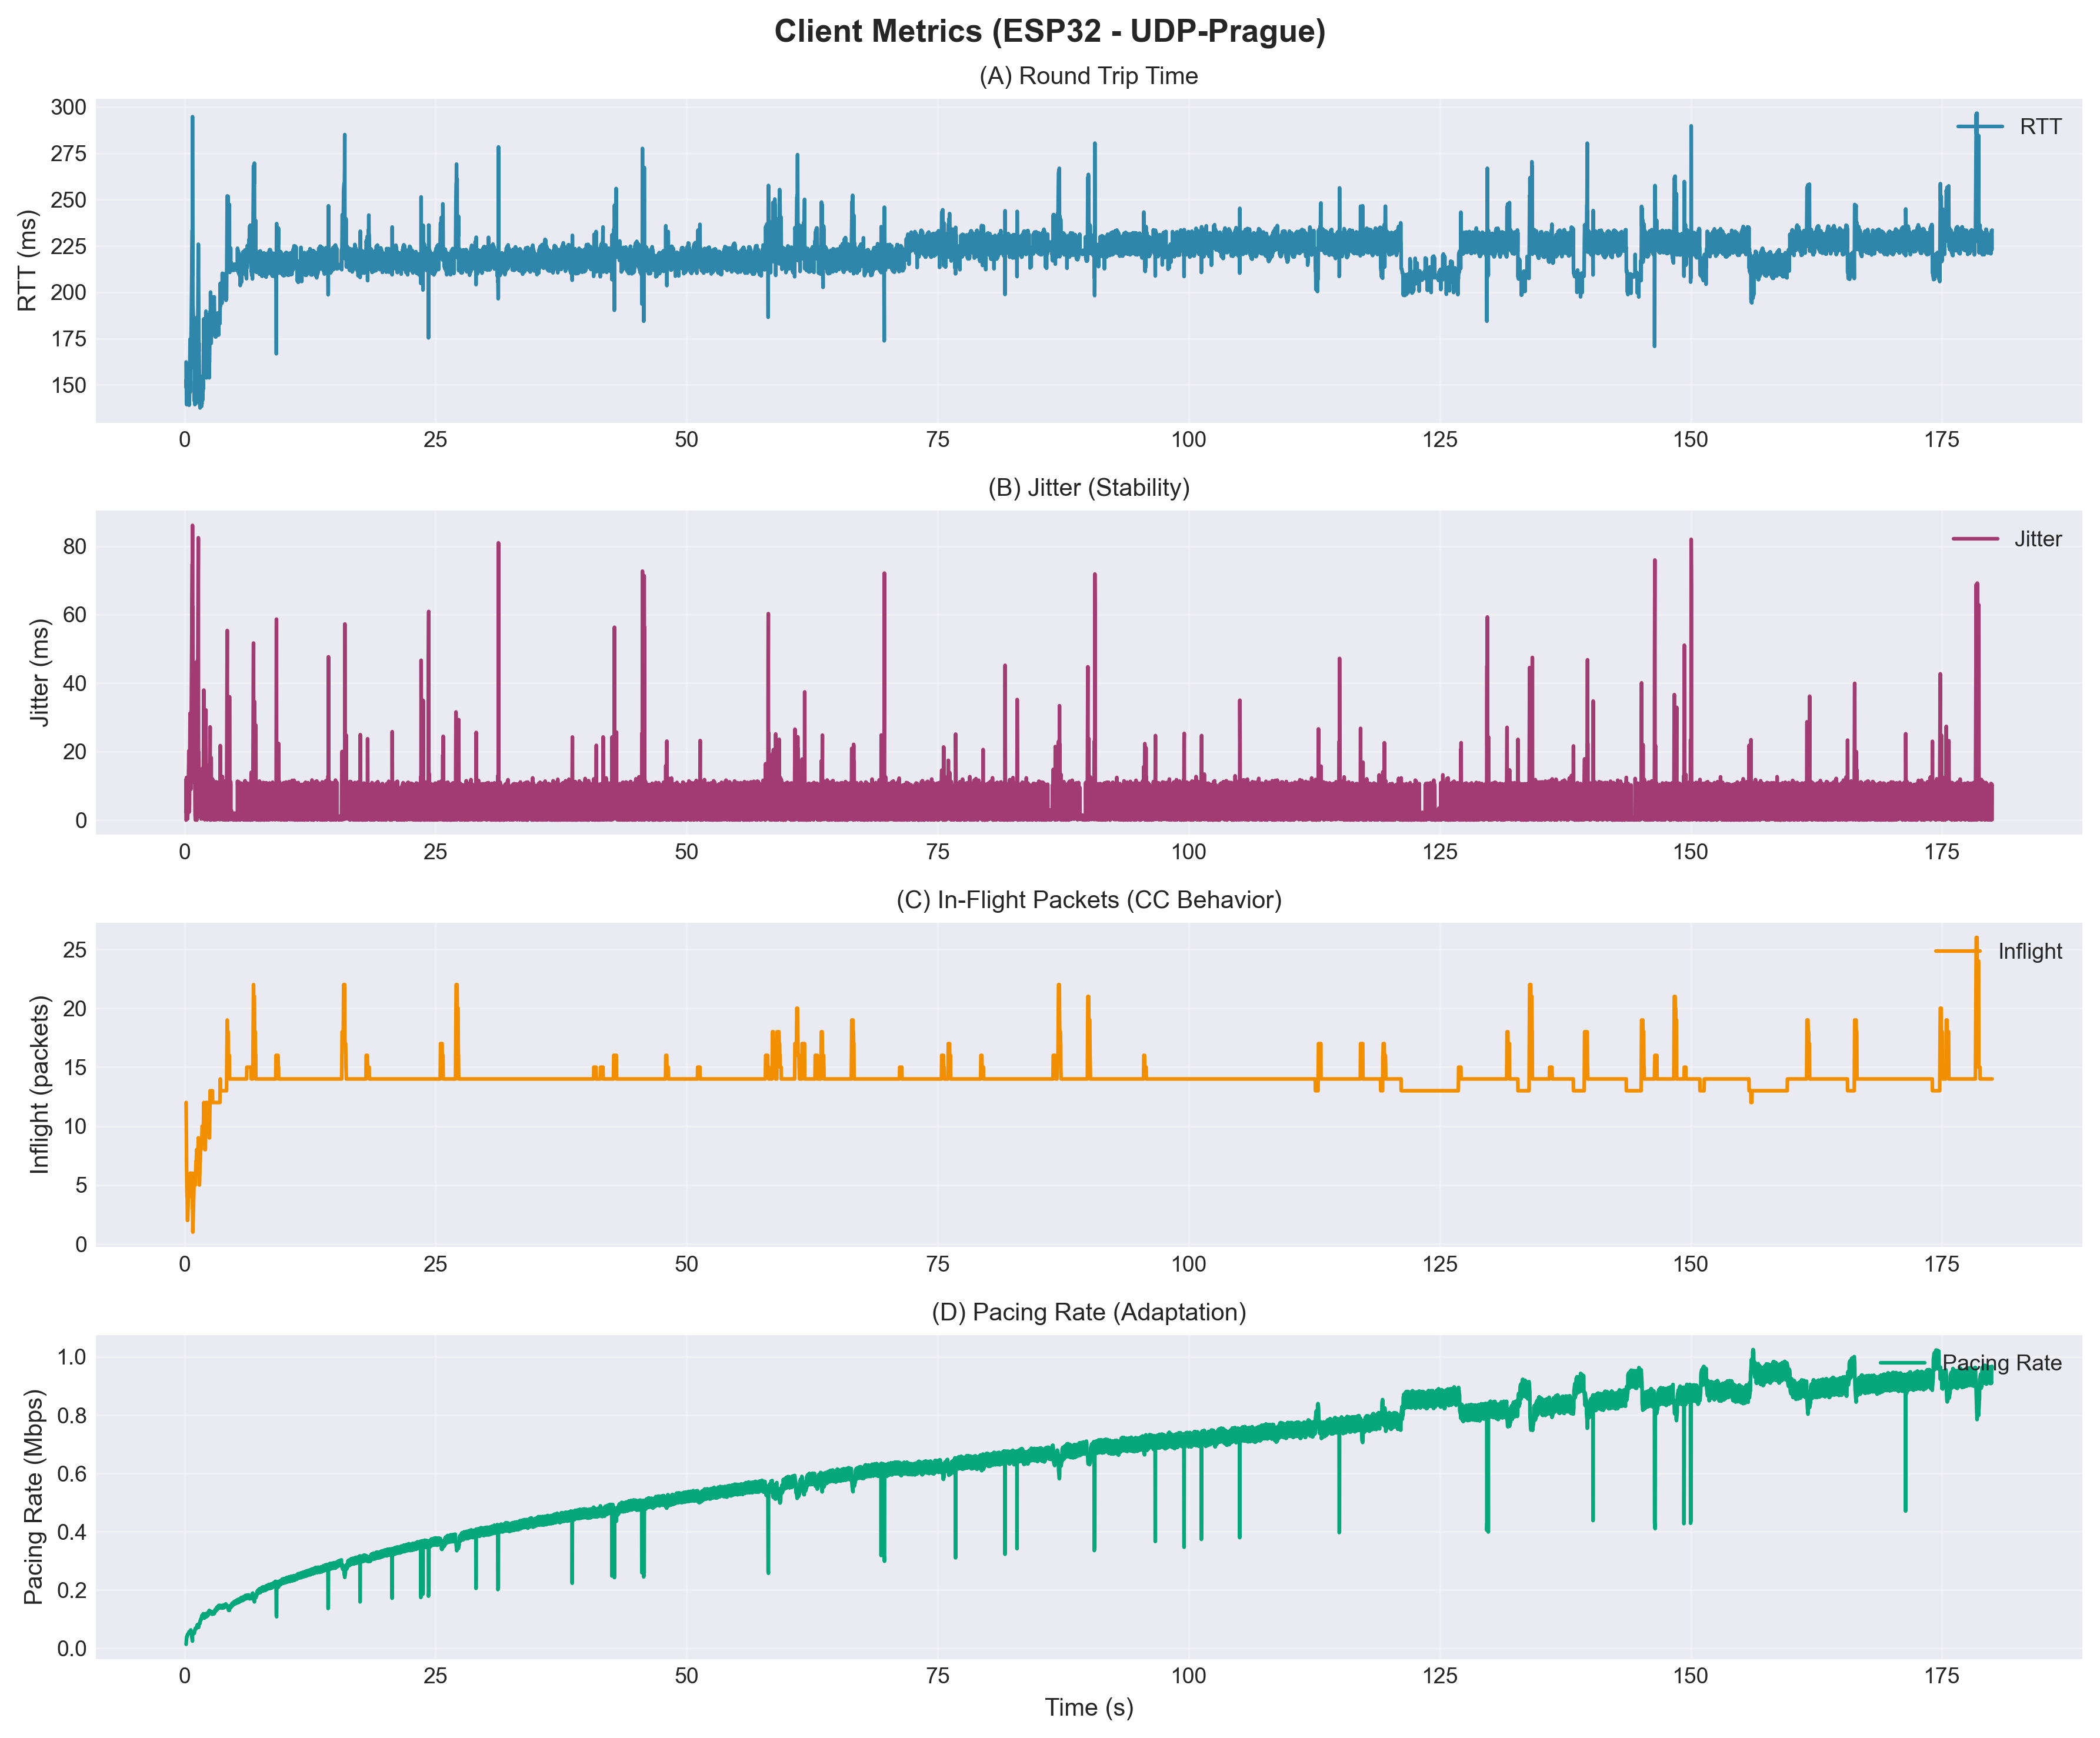

✓ Saved: prague_academic_high_load_node1_ccreno_qdiscfq_codel_ecn0_server_metrics.png


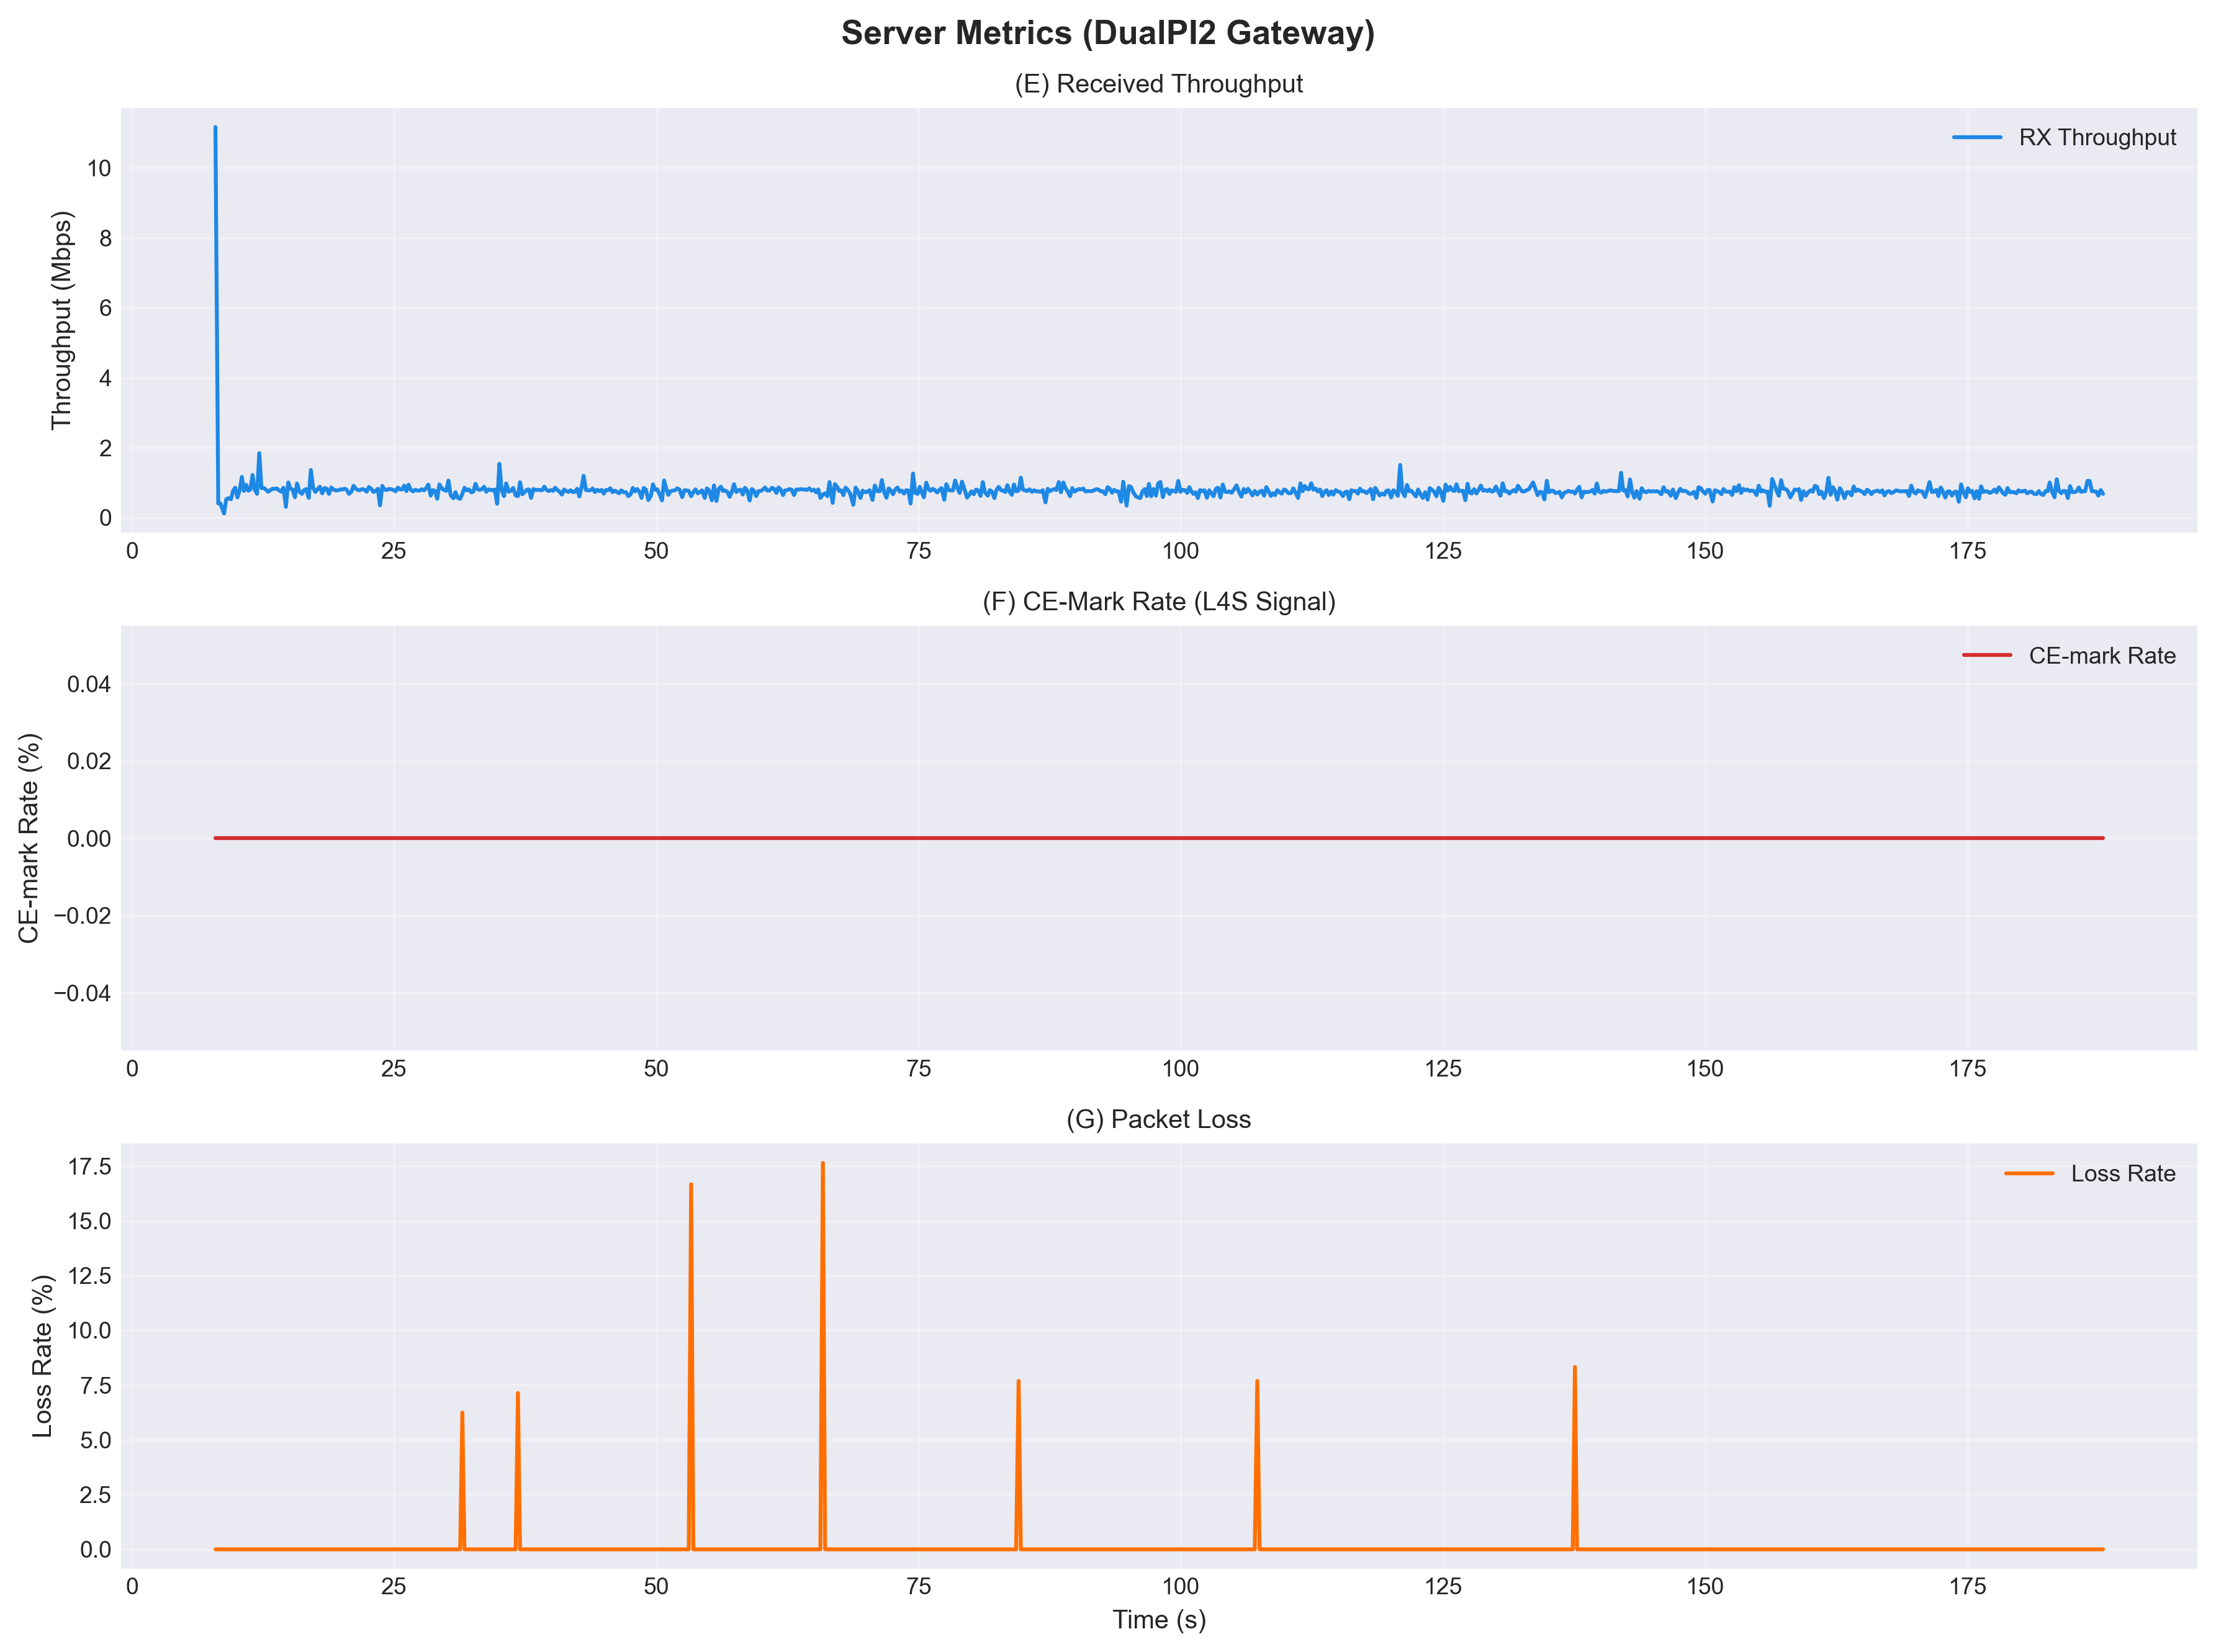

✓ Saved: prague_academic_high_load_node1_ccreno_qdiscfq_codel_ecn0_rtt_cdf.png


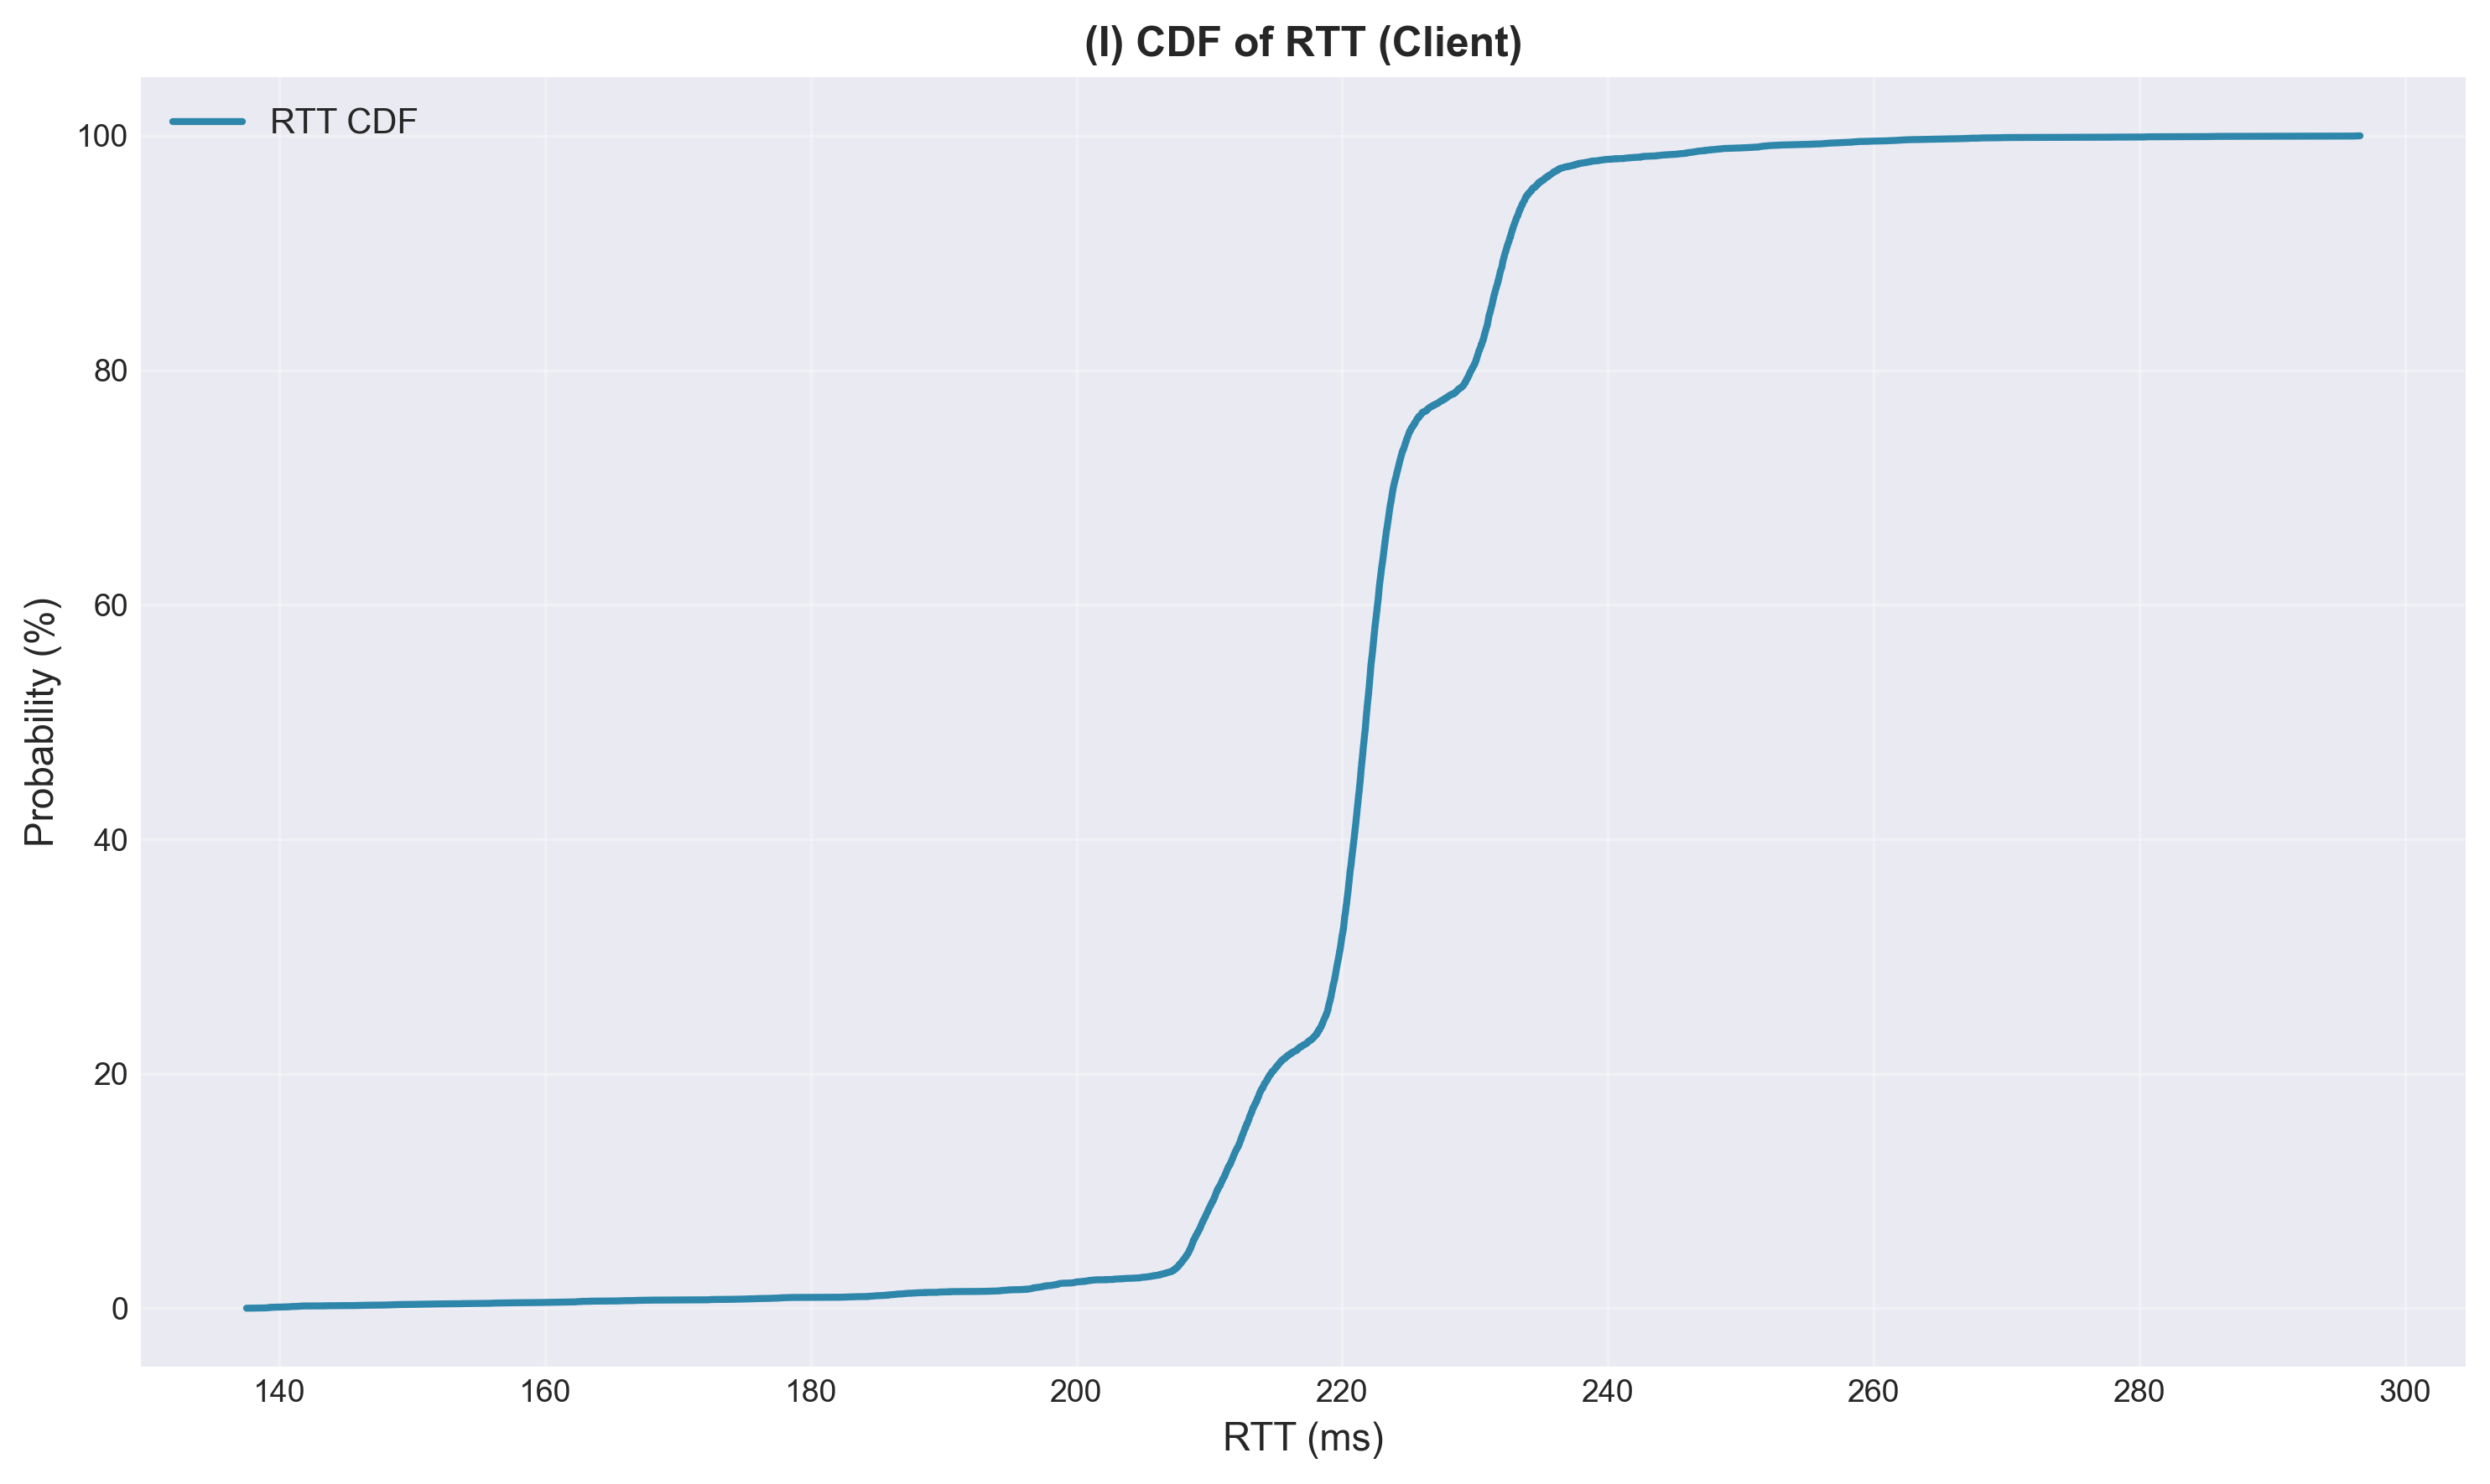

In [133]:
# Generate output filename from metadata
def build_output_name(metadata):
    parts = ['prague_academic']
    
    scenario = metadata.get('Test Scenario', '').lower().replace(' ', '_')
    if scenario:
        parts.append(scenario)
    
    node = metadata.get('IoT Node ID', '')
    if node:
        digits = re.findall(r'\d+', node)
        if digits:
            parts.append(f'node{digits[0]}')
    
    cc = metadata.get('Gateway CC Algorithm', '').lower().replace(' ', '_')
    if cc:
        parts.append(f'cc{cc}')
    
    qdisc = metadata.get('Gateway Qdisc', '').lower().replace(' ', '_')
    if qdisc:
        parts.append(f'qdisc{qdisc}')
    
    ecn = metadata.get('ECN', '')
    if ecn:
        parts.append(f'ecn{ecn}')

    return '_'.join(parts)

base_name = build_output_name(metadata)
print(f"Output name: {base_name}")

# Plot and save client metrics
if not df_client.empty:
    fig = plot_client_metrics(df_client, metadata)
    if fig:
        fname = f"{base_name}_client_metrics.png"
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {fname}")
        plt.show()

# Plot and save server metrics
if not df_server.empty:
    fig = plot_server_metrics(df_server, metadata)
    if fig:
        fname = f"{base_name}_server_metrics.png"
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {fname}")
        plt.show()

# Plot and save CDF of RTT
if not df_client.empty:
    fig = plot_cdf_rtt(df_client)
    if fig:
        fname = f"{base_name}_rtt_cdf.png"
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {fname}")
        plt.show()

## Export CSV

In [134]:
# Export raw data
if not df_client.empty:
    fname_csv = f"{base_name}_client.csv"
    df_client.to_csv(fname_csv, index=False)
    print(f"✓ Saved: {fname_csv}")

if not df_server.empty:
    fname_csv = f"{base_name}_server.csv"
    df_server.to_csv(fname_csv, index=False)
    print(f"✓ Saved: {fname_csv}")

# Summary statistics
if not df_client.empty or not df_server.empty:
    summary = {}
    if not df_client.empty:
        summary.update({
            'client_samples': len(df_client),
            'client_duration_s': df_client['t_client_s'].max() - df_client['t_client_s'].min(),
            'rtt_mean_ms': df_client['rtt_ms'].mean(),
            'rtt_p50_ms': df_client['rtt_ms'].median(),
            'rtt_p95_ms': df_client['rtt_ms'].quantile(0.95),
            'rtt_p99_ms': df_client['rtt_ms'].quantile(0.99),
            'jitter_mean_ms': df_client['jitter_ms'].mean(),
            'inflight_mean': df_client['inflight'].mean(),
            'pacing_rate_mean_mbps': df_client['pacing_rate_mbps'].mean(),
        })
    if not df_server.empty:
        summary.update({
            'server_samples': len(df_server),
            'server_duration_s': df_server['time_sec'].max() - df_server['time_sec'].min(),
            'rx_throughput_mean_mbps': df_server['rcvd_rate_mbps'].mean(),
            'rx_throughput_min_mbps': df_server['rcvd_rate_mbps'].min(),
            'rx_throughput_max_mbps': df_server['rcvd_rate_mbps'].max(),
            'ce_mark_rate_mean_percent': df_server['ce_rate_percent'].mean(),
            'loss_rate_mean_percent': df_server['loss_rate_percent'].mean(),
        })
    
    # Add transmission analysis stats
    if 'transmission_stats' in globals():
        summary.update(transmission_stats)
    
    summary_df = pd.DataFrame([summary])
    fname_summary = f"{base_name}_summary.csv"
    summary_df.to_csv(fname_summary, index=False)
    print(f"✓ Saved: {fname_summary}")
    print(f"\n📊 Summary Statistics:")
    print(summary_df.T)


✓ Saved: prague_academic_high_load_node1_ccreno_qdiscfq_codel_ecn0_client.csv
✓ Saved: prague_academic_high_load_node1_ccreno_qdiscfq_codel_ecn0_server.csv
✓ Saved: prague_academic_high_load_node1_ccreno_qdiscfq_codel_ecn0_summary.csv

📊 Summary Statistics:
                                      0
client_samples             1.144400e+04
client_duration_s          1.798270e+02
rtt_mean_ms                2.214794e+02
rtt_p50_ms                 2.217815e+02
rtt_p95_ms                 2.339877e+02
rtt_p99_ms                 2.507741e+02
jitter_mean_ms             5.297262e+00
inflight_mean              1.405391e+01
pacing_rate_mean_mbps      6.418104e-01
server_samples             8.440000e+02
server_duration_s          1.799400e+02
rx_throughput_mean_mbps    7.769645e-01
rx_throughput_min_mbps     1.220000e-01
rx_throughput_max_mbps     1.116800e+01
ce_mark_rate_mean_percent  0.000000e+00
loss_rate_mean_percent     8.462085e-02
packet_size_bytes          1.396000e+03
client_packets_sent   